In [4]:
import numpy as np
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import copy
from flow_network import FlowNetwork
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyArrowPatch
import helper as h

%load_ext autoreload
%autoreload 2

Nodes: 20, Edges: 37
Degree min/max/mean: 2/4/3.70


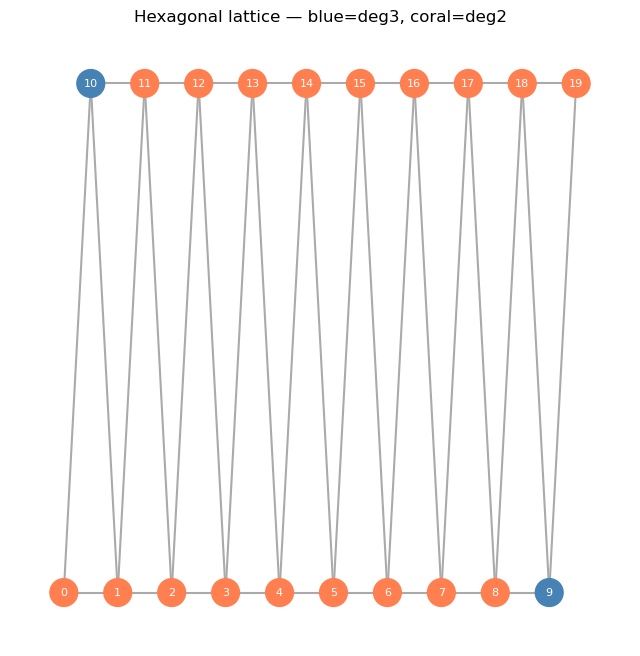

In [43]:


def hex_positions(rows, cols):
    """Generate flat hexagonal lattice positions."""
    pos = {}
    node = 0
    for r in range(rows):
        for c in range(cols):
            x = c * 1.0 + (r % 2) * 0.5   # offset every other row
            y = r * np.sqrt(3) / 2
            pos[node] = np.array([x, y])
            node += 1
    return pos

def random_flat_graph(n_rows=6, n_cols=6):
    pos_all = hex_positions(n_rows, n_cols)
    nodes = list(pos_all.keys())
    coords = np.array([pos_all[nd] for nd in nodes])
    
    # connect nodes closer than 1.1 (hex edge length = 1)
    G = nx.Graph()
    G.add_nodes_from(nodes)
    for i in range(len(nodes)):
        for j in range(i+1, len(nodes)):
            if np.linalg.norm(coords[i] - coords[j]) < 1.1:
                G.add_edge(nodes[i], nodes[j])
    
    W = nx.to_numpy_array(G)
    degrees = np.array([d for _, d in G.degree()])
    print(f"Nodes: {G.number_of_nodes()}, Edges: {G.number_of_edges()}")
    print(f"Degree min/max/mean: {degrees.min()}/{degrees.max()}/{degrees.mean():.2f}")
    return W, pos_all


def plot_flat_graph(W, pos):
    G = nx.from_numpy_array(W)
    degrees = np.array([d for _, d in G.degree()])
    node_colors = ['steelblue' if d == 3 else 'coral' for d in degrees]
    
    fig, ax = plt.subplots(figsize=(8, 8))
    nx.draw(G, pos=pos, ax=ax,
            with_labels=True,
            node_color=node_colors,
            node_size=400,
            font_color='white',
            font_size=8,
            edge_color='#aaaaaa',
            width=1.5)
    ax.set_title(f"Hexagonal lattice — blue=deg3, coral=deg2")
    plt.show()


# Example
W, pos = random_flat_graph(n_rows=2, n_cols=10)
plot_flat_graph(W, pos)

In [ ]:
# Build weighted graph
G = nx.from_numpy_array(W)
net = FlowNetwork(W)
# Incidence matrix B (edges x nodes)
B = - nx.incidence_matrix(G, oriented=True).toarray()
# print("Incidence matrix B:\n", B)

# Diagonal matrix of conductances
edges = list(G.edges())
A = np.diag([G[u][v]['weight'] for u, v in edges])
# print("radii matrix A:\n", A)

Each edge satisfies the equation
$p_j - p_i = \dot{Q}/K + Q/C$

In a matrix form, for edge vectors it can be written as 
$B^T \bold{V} = K^{-1} \bold{\dot{Q}} + C^{-1} \bold{Q}$ (1)


In addition, Kirchof's law per node is brought by $\bold{B}\bold{\dot{Q}}=\bold{I}_{ext}$

Multiply (1) by $\bold{B}$:

$BB^T \bold{V} = K^{-1} B\bold{\dot{Q}} + C^{-1} B\bold{Q}$

$\iff L \bold{V} = K^{-1} \bold{I}_{ext} + C^{-1} B\bold{Q}$

$\iff \bold{I}_{ext} = KL \bold{V}  + KC^{-1} B\bold{Q}$


<>:18: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
<>:18: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
/tmp/ipykernel_44462/93921301.py:18: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
  h.plot_edge_property(G, pos, sh_eigenvectors[:, i], v_min=v_min, v_max=v_max, title=f"Eigenvector {i}, $\lambda_{i}$={np.round(eigenvalues[i], 2)}")


20


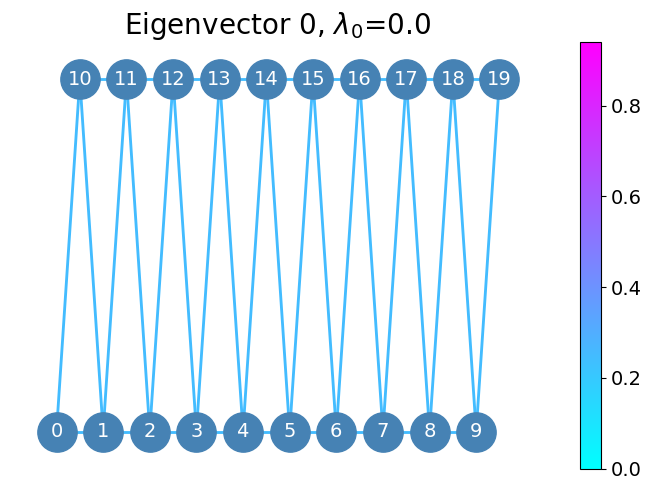

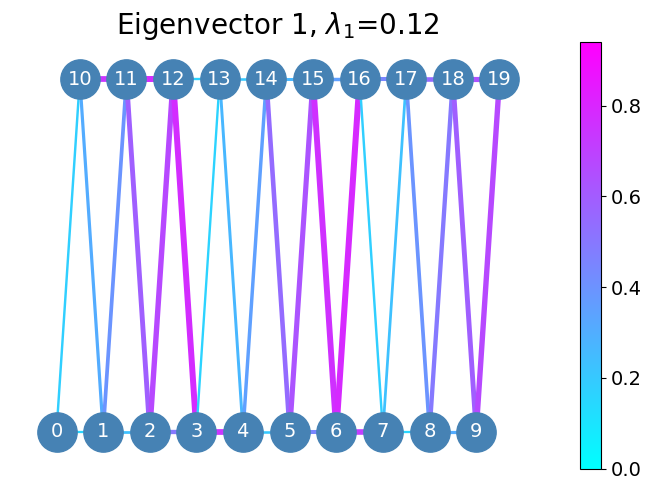

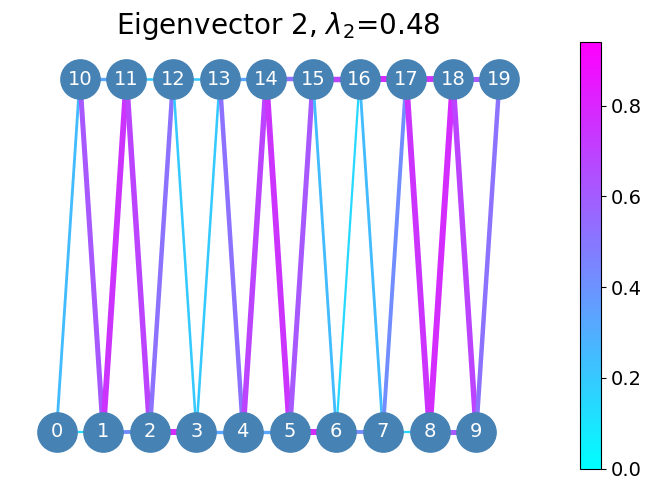

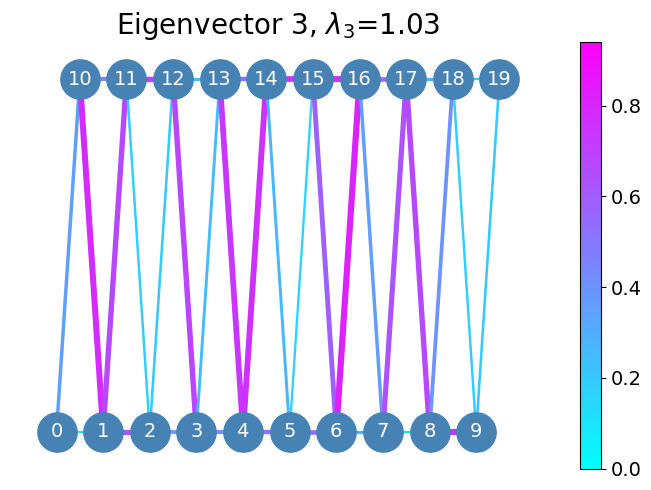

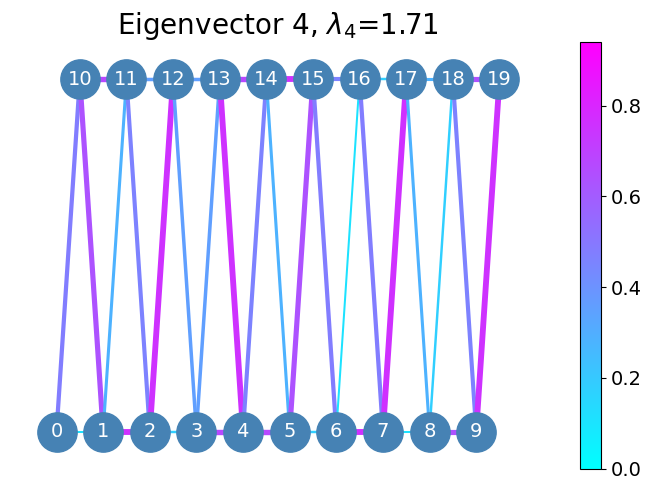

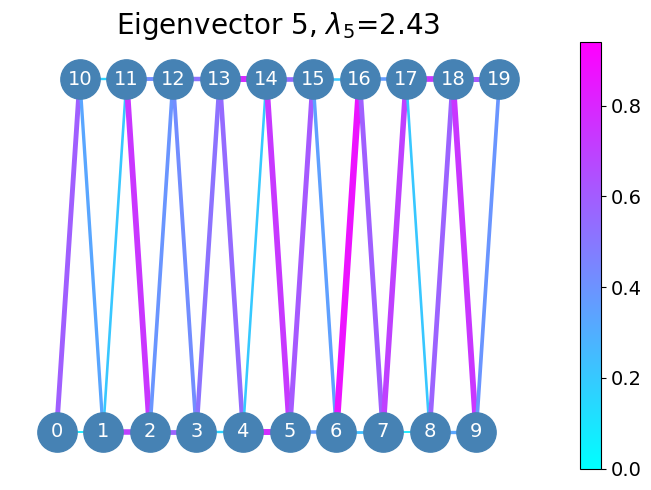

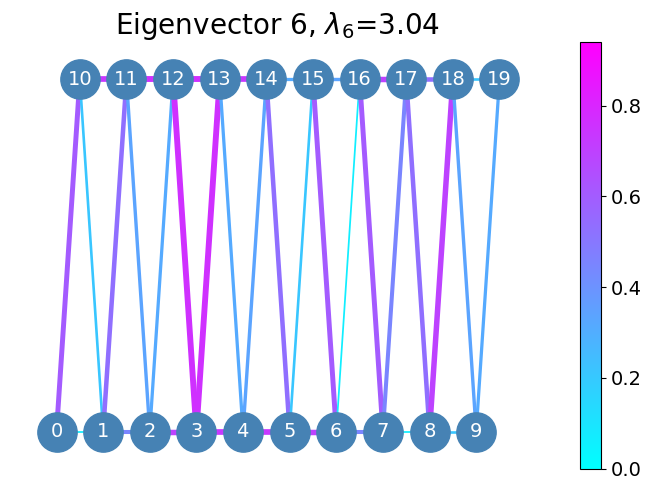

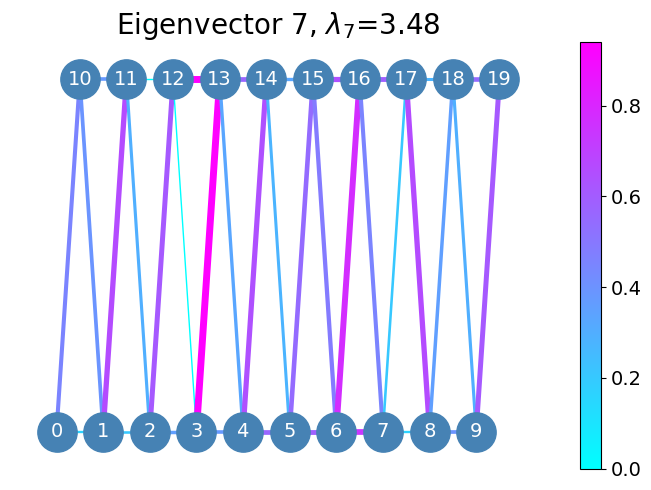

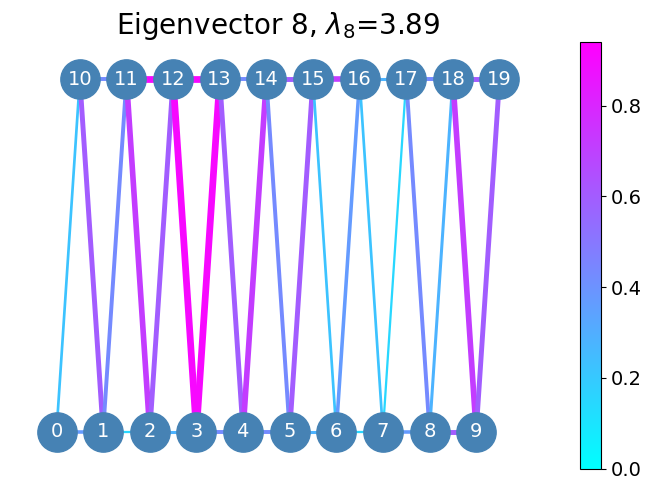

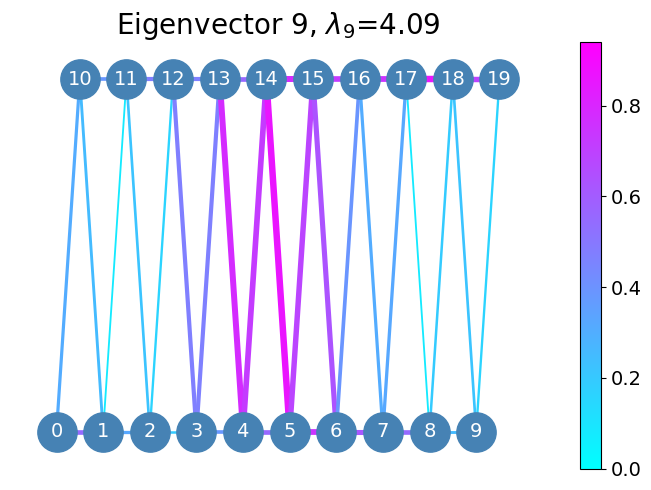

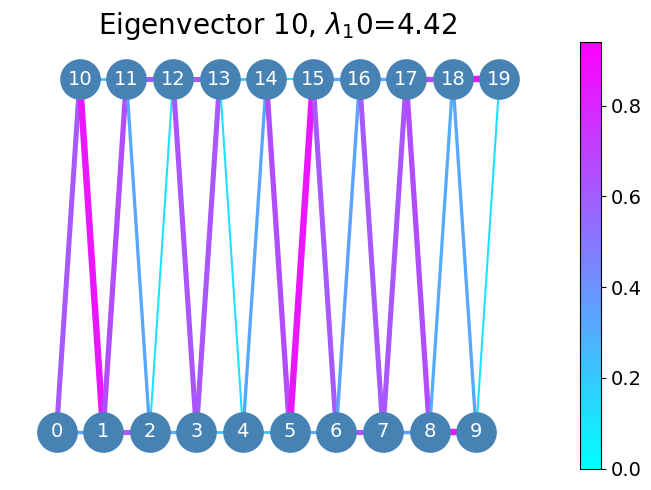

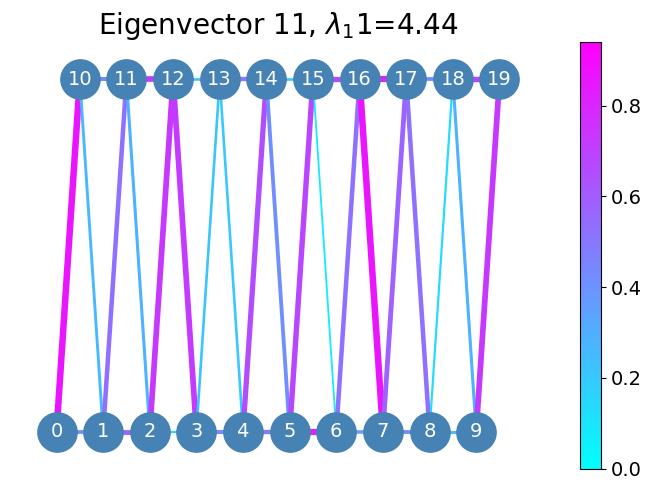

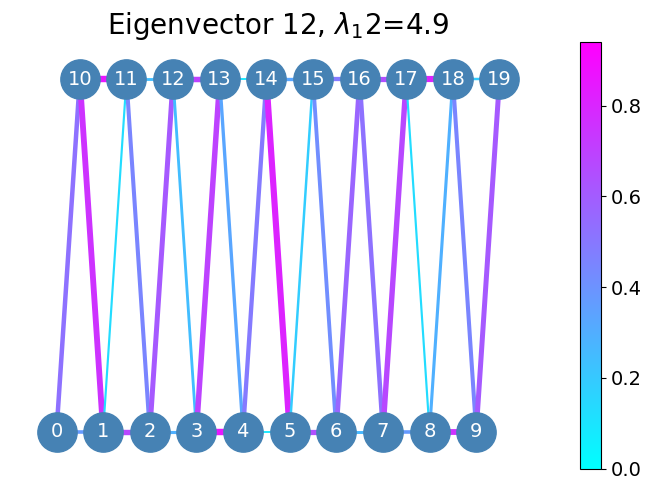

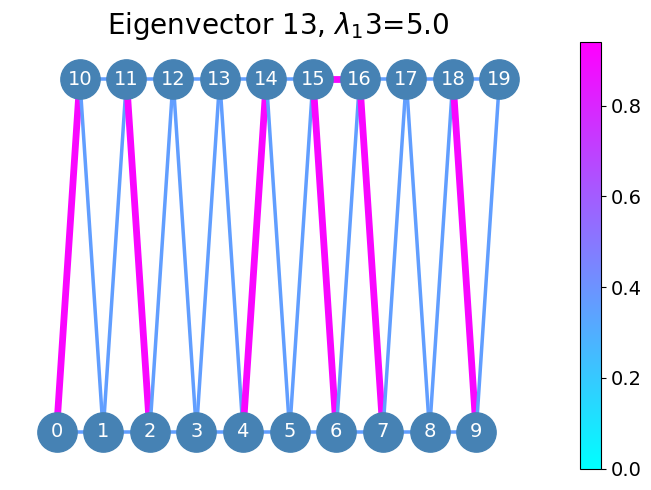

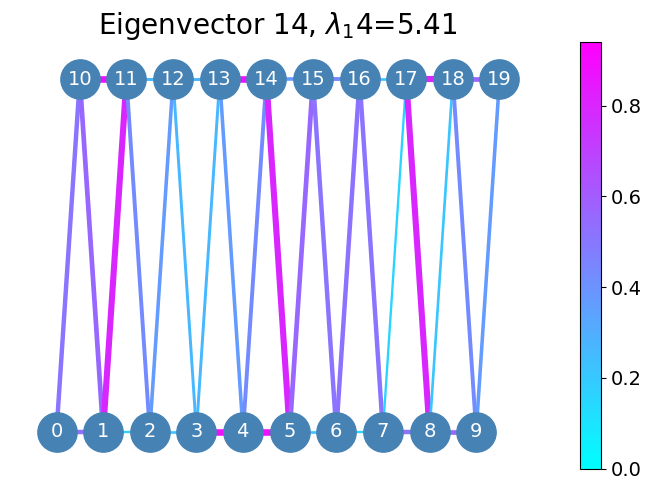

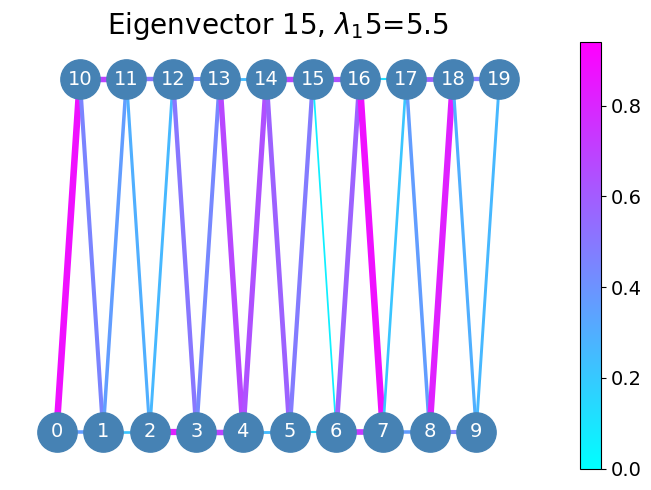

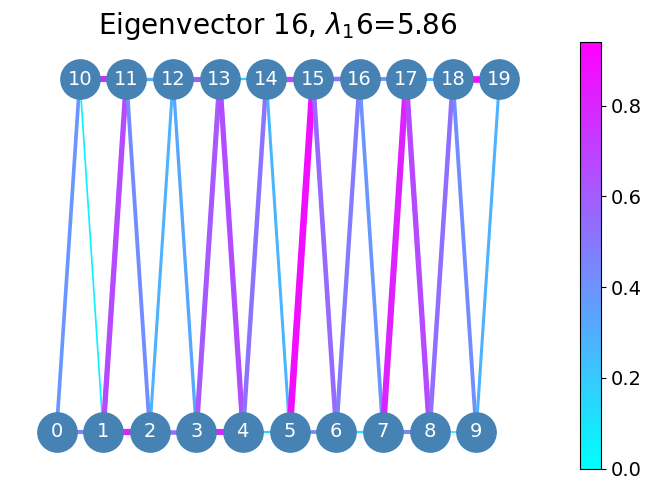

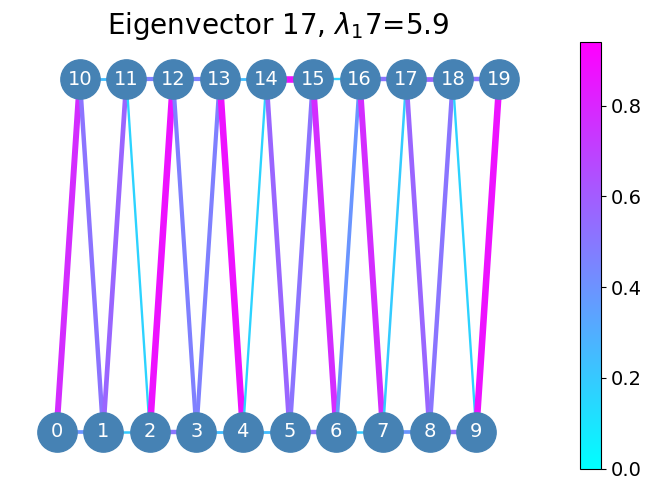

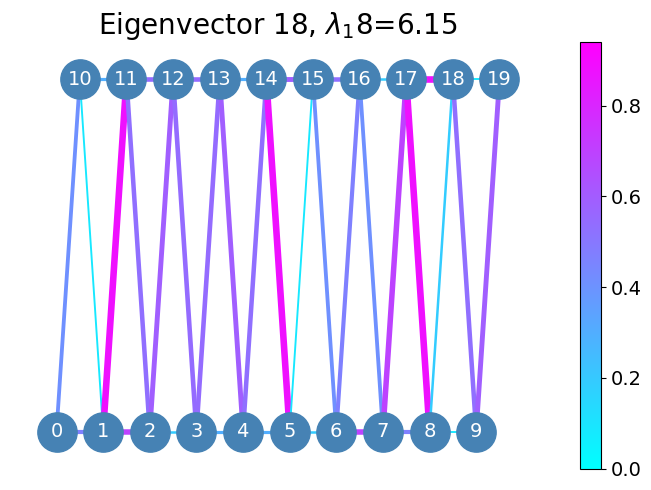

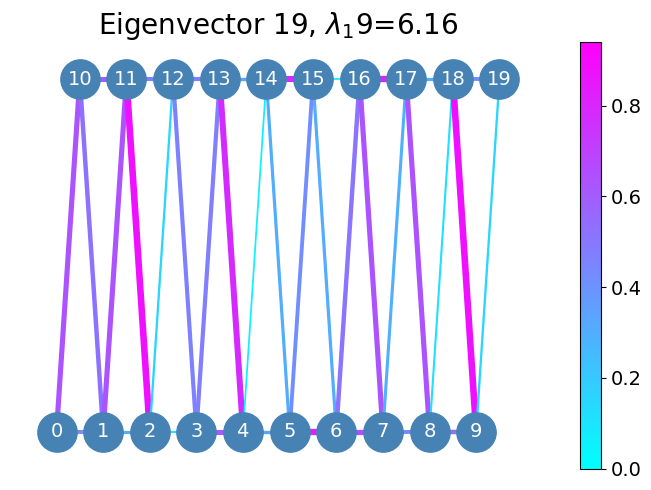

In [ ]:
# Diagonalize the weighted Laplacian L = B^T A B, plot eigenvectors on the graph

L_weighted = nx.laplacian_matrix(G).toarray()

# diagonalize L, get eigenvalues and eigenvectors in ascending order, plot eigenvectors on the graph
eigenvalues, eigenvectors = np.linalg.eig(L_weighted)
# Sort eigenvalues and eigenvectors in ascending order
idx = np.argsort(eigenvalues)
eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]
sh_eigenvectors = eigenvectors - np.min(eigenvectors)

v_min = np.min(sh_eigenvectors)
v_max = np.max(sh_eigenvectors)

# plot 3 exmaple eignevectors-eigenvalue pairs
print(len(eigenvalues))
# for i in [1,(len(eigenvalues)-1)//2,len(eigenvalues)-1]:
for i in range(len(eigenvalues)):
    h.plot_edge_property(G, pos, sh_eigenvectors[:, i], v_min=v_min, v_max=v_max, title=f"Eigenvector {i}, $\lambda_{i}$={np.round(eigenvalues[i], 2)}")
